# Middleware in LangChain

## Context

[LangChain](https://docs.langchain.com/) aims to make it easy to build LLM applications. One type of LLM application you can build is an agent. Agents are exciting because they can automate a wide range of tasks that were previously impossible. 

In practice though, it is incredibly difficult to build systems that reliably execute on these tasks as more control is often necessary. You might need an agent to always call a specific tool first or use different prompts based on its state. 

You can acheive this control through implementing middleware, which we're going to learn about today through building an agent in [LangGraph](https://docs.langchain.com/oss/python/langgraph/overview), a framework for building agent and multi-agent applications that lives on top of LangChain.

## Goals

This module walks through the core agent loop and why middleware matters.

First, you'll build your own AI agent.

Then you'll add middleware for more control.

You'll also add some custom middleware for even more specifc use cases.

Then, you'll inspect the traces created in LangSmith Studio.

Let's get started with the core agent loop.

In [7]:
%%capture --no-stderr
%pip install --quiet -U langchain langchain-core langchain-openai langgraph langchain-community wikipedia python-dotenv rich


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## The Core Agent Loop

The core agent loop involves calling a model, letting it choose which [tool](https://docs.langchain.com/oss/python/langchain/tools) to execute, and finishing the loop when it calls no more tools.

A tool is an external function, capability, or API that allows an artificial intelligence to interact with the outside world.

This pattern is called the [ReAct](https://docs.langchain.com/oss/python/langchain/agents) loop, a general agent architecture.

- `act` - let the model call specific tools
- `observe` - pass the tool output back to the model
- `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

This loop is useful because the same agent structure works whether the tools search data, call APIs, update records, or perform calculations.

<img src="assets/core_agent_loop.avif" alt="Core agent loop" width="300"/>


## Middleware

[Middleware](https://docs.langchain.com/oss/python/langchain/middleware/overview) exposes hooks right before and after each one of these steps.

<img src="assets/middleware_final.avif" alt="Middleware hooks in the agent loop" width="300"/>

A hook is a point in the agent loop where you can plug in your own code.

Hooks can run at any of these points: 
- **before_agent / after_agent** - once per agent invocation
- **before_model / after_model** - around each model call inside the loop
- **wrap_model_call** - wraps the model call itself
- **wrap_tool_call** - wraps each tool execution

Use middleware when your flow is more than the basic “call the model, run tools, repeat until done” loop.

## Middleware Use Cases

Middleware lets you add behavior around the agent loop without rewriting the agent itself. In this module, we'll focus on four practical patterns:

### 1. Human approval

Some actions should pause before they run. For example, a refund agent can ask for approval before issuing a refund.

This is useful for actions that are expensive, irreversible, sensitive, or require a reviewer.

### 2. Custom tool gating

Sometimes the approval rule is more specific than "always pause before this tool." For example, only refunds over $100 should require approval.

Custom middleware lets you inspect the tool call, apply application logic, and decide whether to continue, interrupt, or reject the action.

### 3. Task planning

Some user requests have multiple steps. For example, a trip planning agent needs to check weather, build a packing list, and suggest an activity.

Todo list middleware gives the agent a planning tool so the trace shows how it breaks the task down and completes each step.

### 4. Conversation summarization

Long-running agents collect a lot of context. For example, a research agent may gather information from several Wikipedia pages before writing a final answer.

Summarization middleware compresses older messages while keeping recent messages available, so the agent can continue with the important context preserved.

We'll also view these agents in LangGraph Studio so you can inspect messages, tool calls, interrupts, state, and traces.


## Prebuilt Middleware

LangChain ships a library of prebuilt middlewares for common needs. A few examples from the [full list](https://docs.langchain.com/oss/python/langchain/middleware/built-in):

- `HumanInTheLoopMiddleware`: pause execution so a human can approve, edit, or reject a tool call before it runs.
- `TodoListMiddleware`: give the agent a todo list tool so it can plan multi-step tasks, track progress, and complete each step in order.
- `SummarizationMiddleware`: compress old conversation history when the context window fills up.

You can also write your own middleware by implementing hooks around the agent loop. We'll explore this later with a custom refund gate that uses `wrap_tool_call`.



## Let's Build an Agent

First, pass in your API keys here. You can decide to use a different model provider if you'd like.

In [2]:
import getpass
import os

from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

In [3]:
if not os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("LANGSMITH_API_KEY: ")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy-middleware"

### Refund Agent With Tools

Lets create a customer refund support agent with `create_agent()`:

1. Read the conversation so far.
2. Call the model to decide the next step.
3. If the model asks for a tool, run that tool.
4. Add the tool result back into the conversation.
5. Repeat until the model gives a final answer.

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I'd like a refund on order A100. It arrived damaged.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: lookup_order                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100"                                                                                            │
│ }                                                                                                               │
│    ID: call_0PdLchpSBflMMEEN53CGjYLo                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ delivered, total $45.00                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: issue_refund                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100",                                                                                           │
│   "reason": "Arrived damaged"                                                                                   │
│ }                                                                                                               │
│    ID: call_QTvNzxgv8n2n78LdsvBuSPUn                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Refund processed for order A100. Reason: Arrived damaged                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Your refund for order A100 has been processed. The reason for the refund is that the item arrived damaged. If   │
│ you have any more questions or need further assistance, feel free to ask!                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

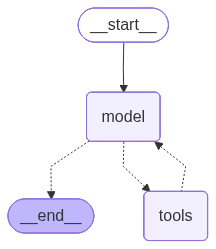

In [4]:
from langchain.agents import create_agent
from langchain_core.tools import tool
from IPython.display import Image, display
from utils import format_messages


@tool
def lookup_order(order_id: str) -> str:
    """Look up a customer's order by ID."""
    orders = {
        "A100": "delivered, total $45.00",
        "B200": "delivered, total $120.00",
    }
    return orders.get(order_id, "order not found")


@tool
def issue_refund(order_id: str, reason: str) -> str:
    """Issue a refund for a customer's order."""
    return f"Refund processed for order {order_id}. Reason: {reason}"


refund_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[lookup_order, issue_refund],
    system_prompt="You are a customer refund support agent. Look up the order and issue a refund when a customer requests one.",
)

result = refund_agent.invoke(
    {"messages": [{"role": "user", "content": "I'd like a refund on order A100. It arrived damaged."}]}
)

format_messages(result["messages"])

display(Image(refund_agent.get_graph(xray=True).draw_mermaid_png()))


### What just happened, and what's missing

The agent looked up order A100, decided $45 was the right refund amount, issued the refund, and replied. All on its own, with no human in the loop.

The problem in production though is there's no checkpoint where a person can step in. If the model hallucinates the amount, picks the wrong order, or gets talked into refunding something it shouldn't, the refund still fires.

This is something middleware can prevent, let's implement it now.


## Refund Agent With Built-In Human In The Loop Middleware

For our refund agent, `HumanInTheLoopMiddleware` ([HITL](https://docs.langchain.com/oss/python/langchain/middleware/built-in#human-in-the-loop)) is the right pick.

Looking up order information is not a high stakes action. The agent should freely be able to find the info on the order as needed.

Refunds though are a high-stakes action. We don't want the agent issuing one without a human signing off.

HITL pauses the loop right before `issue_refund` fires, surfaces the proposed call to a person, and only proceeds once they approve.

Pending action:
[Interrupt(value={'action_requests': [{'name': 'issue_refund', 'args': {'order_id': 'A100', 'reason': 'Item arrived damaged.'}, 'description': "Tool execution requires approval\n\nTool: issue_refund\nArgs: {'order_id': 'A100', 'reason': 'Item arrived damaged.'}"}], 'review_configs': [{'action_name': 'issue_refund', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='f31b4b7d7f3e10ed55c176ab2106ab53')]
Approve this refund? (y/n):  Y


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: lookup_order                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100"                                                                                            │
│ }                                                                                                               │
│    ID: call_WrW331Oslv3yzEtIKmFSCCnZ                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ delivered, total $45.00                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: issue_refund                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100",                                                                                           │
│   "reason": "Item arrived damaged."                                                                             │
│ }                                                                                                               │
│    ID: call_jmvauiIRXZmn9FAQzyVLCuJh                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Refund processed for order A100. Reason: Item arrived damaged.                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Your refund for order A100 has been successfully processed due to the item arriving damaged. If you have any    │
│ further questions or need assistance, feel free to ask!                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

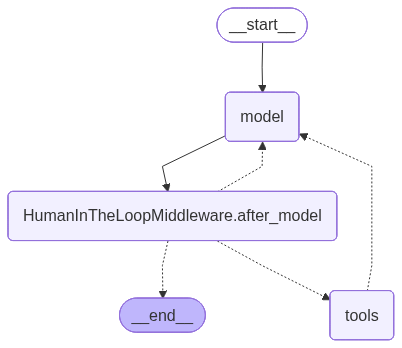

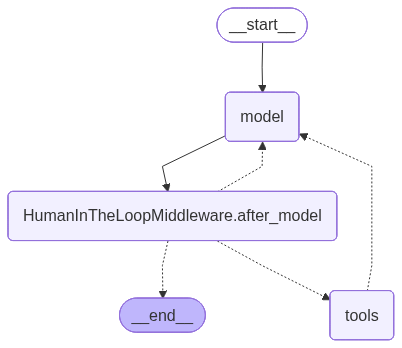

In [14]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import MemorySaver # in-memory state snapshots; required so interrupt() can pause and continue
from langgraph.types import Command
from IPython.display import Image, display
from utils import format_messages

@tool
def lookup_order(order_id: str) -> str:
    """Look up a customer's order by ID."""
    orders = {
        "A100": "delivered, total $45.00",
        "B200": "delivered, total $120.00",
    }
    return orders.get(order_id, "order not found")


@tool
def issue_refund(order_id: str, reason: str) -> str:
    """Issue a refund for a customer's order."""
    return f"Refund processed for order {order_id}. Reason: {reason}"


refund_agent_with_hitl = create_agent(
    model="openai:gpt-4o-mini",
    tools=[lookup_order, issue_refund],
    system_prompt="You are a customer refund support agent. Look up the order and issue a refund when a customer requests one.",
    checkpointer=MemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "issue_refund": {"allowed_decisions": ["approve", "edit", "reject"]},
            }
        )
    ],
)

config = {"configurable": {"thread_id": "refund-session-1"}}

result = refund_agent_with_hitl.invoke(
    {"messages": [{"role": "user", "content": "I'd like a refund on order A100. It arrived damaged."}]},
    config=config,
)

if "__interrupt__" in result:
    print("Pending action:")
    print(result["__interrupt__"])

    decision = input("Approve this refund? (y/n): ").strip().lower()

    if decision == "y":
        result = refund_agent_with_hitl.invoke(
            Command(resume={"decisions": [{"type": "approve"}]}),
            config=config,
        )
    else:
        result = refund_agent_with_hitl.invoke(
            Command(resume={"decisions": [{"type": "reject", "feedback": "Rejected by reviewer"}]}),
            config=config,
        )

format_messages(result["messages"])

display(Image(refund_agent_with_hitl.get_graph(xray=True).draw_mermaid_png()))


### Retrospective

<img src="assets/RefundAgent.svg" alt="Refund agent with built-in HITL middleware" width="300"/>

- The built-in HITL middleware paused before the refund tool ran, so a reviewer could approve or reject the action.
- The formatted messages make it easier to see what happened before and after the approval step.
- To view this flow in LangGraph Studio, expose the agent from a Python file and run `langgraph dev`. Studio will let you inspect the run, state, tool calls, and interrupt/resume behavior.


## Refund Agent With Custom HITL Middleware

Built-in HITL pauses on every refund. In practice, that's a little blunt.

Most refunds are small and routine. Only the high-dollar ones need human eyes.

`wrap_tool_call` lets us write a custom gate. It checks the proposed refund amount, pauses only when it exceeds $100, and lets smaller refunds flow through automatically.



Middleware saw refund request for $45.00


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I'd like a refund on order A100. It arrived damaged.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: lookup_order                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100"                                                                                            │
│ }                                                                                                               │
│    ID: call_s6wZp7POa3ZfSFX5NaV3N9Zz                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ delivered, total $45.00                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: issue_refund                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100",                                                                                           │
│   "amount": 45,                                                                                                 │
│   "reason": "Item arrived damaged."                                                                             │
│ }                                                                                                               │
│    ID: call_Z23pyW5p2JDhjpXQ4y6GpTrE                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Refund of $45.00 processed for order A100. Reason: Item arrived damaged.                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Your refund of $45.00 for order A100 has been successfully processed due to the item arriving damaged. If you   │
│ have any further questions or need assistance, feel free to ask!                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

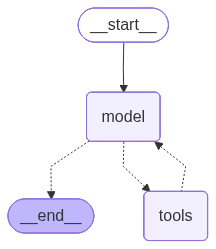

In [16]:
from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver # in-memory state snapshots; required so interrupt() can pause and continue
from langgraph.types import Command, interrupt
from utils import format_messages

@tool
def lookup_order(order_id: str) -> str:
    """Look up a customer's order by ID."""
    orders = {
        "A100": "delivered, total $45.00",
        "B200": "delivered, total $120.00",
    }
    return orders.get(order_id, "order not found")

@tool
def issue_refund(order_id: str, amount: float, reason: str) -> str:
    """Issue a refund for a customer's order."""
    return f"Refund of ${amount:.2f} processed for order {order_id}. Reason: {reason}"

@wrap_tool_call
def refund_threshold_gate(request, handler):
    """Pause for human approval only when the refund amount exceeds $100."""
    if request.tool_call["name"] == "issue_refund":
        amount = request.tool_call["args"].get("amount", 0)

        print(f"\nMiddleware saw refund request for ${amount:.2f}")

        if amount > 100:
            print("Middleware paused execution for approval.")

            decision = interrupt({
                "action": "issue_refund",
                "args": request.tool_call["args"],
                "message": f"Refund of ${amount:.2f} exceeds the $100 threshold. Approve?",
            })

            if not decision.get("approved", False):
                print("Middleware rejected the refund.")

                return ToolMessage(
                    content="Refund rejected by reviewer.",
                    tool_call_id=request.tool_call["id"],
                )

            print("Middleware approved the refund.")

    return handler(request)

gated_refund_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[lookup_order, issue_refund],
    system_prompt=(
        "You are a customer refund support agent. "
        "Look up the order to get the total, then issue a refund for that amount."
    ),
    checkpointer=MemorySaver(),
    middleware=[refund_threshold_gate],
)

config = {"configurable": {"thread_id": "threshold-session-1"}}

result = gated_refund_agent.invoke(
    {"messages": [{"role": "user", "content": "I'd like a refund on order A100. It arrived damaged."}]},
    config=config,
)

if "__interrupt__" in result:
    print("Pending action (over $100 threshold):")
    print(result["__interrupt__"])

    decision = input("Approve this refund? (y/n): ").strip().lower()

    result = gated_refund_agent.invoke(
        Command(resume={"approved": decision == "y"}),
        config=config,
    )

format_messages(result["messages"])

display(Image(gated_refund_agent.get_graph(xray=True).draw_mermaid_png()))


### Refund Agent With Custom HITL Middleware Retrospective

<img src="assets/CustomRefundAgent.svg" alt="Refund agent with custom threshold gate middleware" width="300"/>

- The custom middleware checked the refund amount before allowing the tool call to continue.
- The graph still shows a normal `tools` node because middleware runs inside tool execution rather than as a separate graph node.
- To debug this more deeply, use `langgraph dev` with the agent exposed in `langgraph.json`. That gives you an interactive view of the run even though custom middleware will still appear as behavior inside the tool step.


## Middleware Retrospective

Middleware gives us a way to add behavior around the agent loop without rewriting the agent itself.

In these examples, the agent still follows the same basic pattern: the model decides what to do, tools run when needed, and the model uses the results to continue or respond. 

Middleware lets us add extra control at specific points in that loop, such as pausing for human approval, blocking or editing risky tool calls, tracking todos for multi-step work, or summarizing older messages when the conversation gets long.

The important idea is that middleware changes how the loop behaves around the edges, while the core agent structure stays the same.

## Next Steps: Deep Agents

Deep Agents are a more advanced pattern for custom long-running agents with planning, memory, file systems, and subagents. If you want to build your own more capable agent architecture, Deep Agents are the next layer to explore after these middleware examples.

# More Middleware Examples

## Trip Planning Agent With Todo List Middleware

Trip planning has several small steps: check the weather, build a packing list, and suggest an activity.

`TodoListMiddleware` gives the agent a todo list tool so it can plan the task, track progress, and complete each step in order.

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I'm taking a 3-day work trip to Seattle. Help me check the weather, make a packing list, and suggest one        │
│ evening activity.                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Check the weather for Seattle",                                                               │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Create a packing list for the 3-day work trip to Seattle",                                    │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Suggest one evening activity in Seattle",                                                     │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_djegG5RdEw9ZVPnXtAFEfUwN                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Check the weather for Seattle', 'status': 'pending'}, {'content': 'Create a  │
│ packing list for the 3-day work trip to Seattle', 'status': 'pending'}, {'content': 'Suggest one evening        │
│ activity in Seattle', 'status': 'pending'}]                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: get_weather                                                                                       │
│    Args: {                                                                                                      │
│   "city": "Seattle"                                                                                             │
│ }                                                                                                               │
│    ID: call_Am5K2tFWJFhW1bZPp71tiSdr                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Cool and rainy, around 52°F. Bring a rain jacket.                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Packing list for a 3-day work trip to Seattle: rain jacket, comfortable shoes, laptop, charger, toiletries, two │
│ work outfits, casual evening clothes, and travel documents.                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Visit Pike Place Market and get dinner near the waterfront.                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Check the weather for Seattle",                                                               │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Create a packing list for the 3-day work trip to Seattle",                                    │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Suggest one evening activity in Seattle",                                                     │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_keBSJs44KIvsVK2hVsP58r5E                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Check the weather for Seattle', 'status': 'completed'}, {'content': 'Create  │
│ a packing list for the 3-day work trip to Seattle', 'status': 'completed'}, {'content': 'Suggest one evening    │
│ activity in Seattle', 'status': 'completed'}]                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here's your trip information for Seattle:                                                                       │
│                                                                                                                 │
│ ### Weather                                                                                                     │
│ - **Cool and rainy**, around **52°F**. Don't forget to bring a rain jacket!                                     │
│                                                                                                                 │
│ ### Packing List for a 3-Day Work Trip                                                                          │
│ - Rain jacket                                                                                                   │
│ - Comfortable shoes                                                                                             │
│ - Laptop and charger                                                                                            │
│ - Toiletries                                                                                                    │
│ - Two work outfits                                                                                              │
│ - Casual evening clothes                                                                                        │
│ - Travel documents                                                                                              │
│                                                                                                                 │
│ ### Evening Activity Suggestion                                                                                 │
│ - **Visit Pike Place Market** and get dinner near the waterfront.                                               │
│                                                                                                                 │
│ If you need anything else, feel free to ask!                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

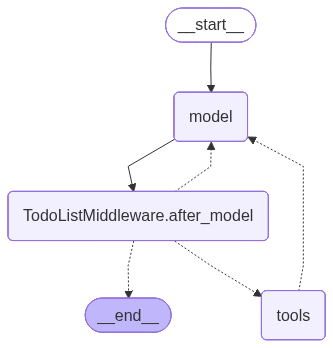

In [18]:
from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware
from langchain_core.tools import tool
from utils import format_messages


@tool
def get_weather(city: str) -> str:
    """Get a simple weather forecast for a city."""
    forecasts = {
        "Seattle": "Cool and rainy, around 52°F. Bring a rain jacket.",
        "Austin": "Warm and sunny, around 78°F. Bring light clothing.",
        "New York": "Mild and breezy, around 60°F. Bring layers.",
    }

    return forecasts.get(city, f"No forecast found for {city}.")


@tool
def make_packing_list(city: str, days: int, trip_type: str) -> str:
    """Create a packing list for a trip."""
    return (
        f"Packing list for a {days}-day {trip_type} trip to {city}: "
        "rain jacket, comfortable shoes, laptop, charger, toiletries, "
        "two work outfits, casual evening clothes, and travel documents."
    )


@tool
def suggest_activity(city: str, time_of_day: str) -> str:
    """Suggest one activity for a city."""
    activities = {
        "Seattle": "Visit Pike Place Market and get dinner near the waterfront.",
        "Austin": "Walk around South Congress and listen to live music.",
        "New York": "Visit the High Line and grab dinner nearby.",
    }

    return activities.get(city, f"No activity suggestion found for {city}.")


trip_planning_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[
        get_weather,
        make_packing_list,
        suggest_activity,
    ],
    system_prompt=(
        "You are a concise trip planning assistant. "
        "For every multi-step trip request, you must first use the todo list tool"
    ),
    middleware=[
        TodoListMiddleware(),
    ],
)


result = trip_planning_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "I'm taking a 3-day work trip to Seattle. "
                    "Help me check the weather, make a packing list, "
                    "and suggest one evening activity."
                ),
            }
        ]
    }
)


format_messages(result["messages"])

display(Image(trip_planning_agent.get_graph(xray=True).draw_mermaid_png()))


<img src="assets/TodoAgent.svg" alt="Trip planning agent with todo list middleware" width="200"/>

### Trip Planning Agent With Todo List Middleware

- The todo middleware gave the agent a `write_todos` tool so it could plan the trip request before completing the steps.
- This is useful for multi-step tasks because the trace shows the agent planning, calling tools, and producing the final answer.
- To inspect the todo tool calls in LangGraph Studio, move this agent into a Python module and run `langgraph dev`. Studio is the best place to view the full run trace and tool call sequence.


## Research Agent With Summarization Middleware

Research agents often collect facts across multiple turns.

`SummarizationMiddleware` compresses older research notes as the conversation grows, while keeping recent messages available. This helps the agent combine information from different topics into one final answer.

C:\Users\Matthew Feroz\AppData\Local\Temp\ipykernel_58256\1472140947.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import WikipediaRetriever


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Look up Ada Lovelace on Wikipedia.                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: fetch_wikipedia_data                                                                              │
│    Args: {                                                                                                      │
│   "query": "Ada Lovelace"                                                                                       │
│ }                                                                                                               │
│    ID: call_MaKZ6kSNVqlU8TWZTmOwa2Eg                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Augusta Ada King, Countess of Lovelace (née Byron; 10 December 1815 – 27 November 1852), also known as Ada      │
│ Lovelace, was an English mathematician and writer chiefly known for work on Charles Babbage's proposed          │
│ mechanical general-purpose computer, the analytical engine. She was the first to recognise the machine had      │
│ applications beyond pure calculation. Lovelace is often considered the first computer programmer.               │
│ Lovelace was the only legitimate child of poet Lord Byron and reformer Anne Isabella Milbanke. Lord Byron       │
│ separated from his wife a month after Ada was born, and died when she was eight. Although often ill in          │
│ childhood, Lovelace pursued her studies assiduously. She married William King in 1835. King was a Baron, and    │
│ was created Viscount Ockham and 1st Earl of Lovelace in 1838. The name Lovelace was chosen because Ada was      │
│ descended from the extinct Baron Lovelaces. The title given to her husband thus made Ada the Countess of        │
│ Lovelace.                                                                                                       │
│ Lovelace's educational and social exploits brought her into contact with scientists such as Andrew Crosse,      │
│ Charles Babbage, David Brewster, Charles Wheatstone and Michael Faraday, and the author Charles Dickens,        │
│ contacts which she used to further her education. Lovelace described her approach as "poetical science" and     │
│ herself as an "Analyst (& Metaphysician)".                                                                      │
│ When she was eighteen, Lovelace's mathematical talents led her to a long working relationship and friendship    │
│ with fellow British mathematician Charles Babbage. She was particularly interested in Babbage's work on the     │
│ analytical engine. Lovelace first met him on 5 June 1833, when she and her mother attended one of Charles       │
│ Babbage's Saturday night soirées with their mutual friend, and Lovelace's private tutor, Mary Somerville.       │
│ Though Babbage's analytical engine was never constructed and did not influence the invention of electronic      │
│ computers, it has been recognised as a Turing-complete general-purpose computer, which anticipated the          │
│ essential features of a modern electronic computer. Babbage is therefore known as the "father of computers,"    │
│ and Lovelace is credited with several computing "firsts" for her collaboration with him. Lovelace translated an │
│ article by the military engineer Luigi Menabrea about the analytical engine, supplementing it with seven long   │
│ explanatory notes. These described a method of using the machine to calculate Bernoulli numbers which is often  │
│ called the first published computer program.                                                                    │
│ She developed a vision of the capability of computers to go beyond mere calculating or number-crunching, while  │
│ many others, including Babbage, focused only on those capabilities. Lovelace was the first to point out the     │
│ possibility of encoding information besides mere arithmetical figures, such as music, and manipulating it with  │
│ such a machine. Her mindset of "poetical science" led her to ask questions about the analytical engine,         │
│ examining how individuals and society relate to technology as a collaborative tool. Ada is widely commemorated, │
│ including in the names of a programming language, roads, buildings and institutes, as well as programmes,       │
│ lectures and courses. There are plaques, statues, paintings, literary and non-fiction works about her.          │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Augusta Ada King, Countess of Lovelace (1815–1852), was an English mathematician and writer, primarily          │
│ recognized for her work on Charles Babbage's proposed analytical engine, which is considered an early form of a │
│ general-purpose computer. She is celebrated as the first computer programmer for her notes and the method she   │
│ developed for the machine to calculate Bernoulli numbers.                                                       │
│                                                                                                                 │
│ Lovelace was the only legitimate child of poet Lord Byron and Anne Isabella Milbanke. Despite a troubled        │
│ childhood marked by illness and a challenging relationship with her mother, she excelled academically. Her      │
│ significant encounter with Babbage in 1833 led to an extensive collaboration that would shape her legacy. She   │
│ envisioned the potential of computers to handle more than just numerical computations, including encoding music │
│ and other forms of information.                                                                                 │
│                                                                                                                 │
│ Later in life, Lovelace engaged with various scientific figures and expressed her ideas through what she termed │
│ "poetical science," reflecting on technology's role in society. Today, her contributions are commemorated       │
│ through various programs, institutions, and even a programming language named after her, Ada.                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: fetch_wikipedia_data                                                                              │
│    Args: {                                                                                                      │
│   "query": "Andrej Karpathy"                                                                                    │
│ }                                                                                                               │
│    ID: call_Q0G8aqTedAvDekYyU0HZHje2                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Andrej Karpathy (born 23 October 1986) is a Slovak-Canadian AI researcher, who co-founded and formerly worked   │
│ at OpenAI, where he specialized in deep learning and computer vision. He also worked as the director of         │
│ artificial intelligence and Autopilot Vision at Tesla, and in 2024 he founded Eureka Labs, an AI education      │
│ platform. In 2026 he joined Anthropic as part of the pretraining team.                                          │
│                                                                                                                 │
│                                                                                                                 │
│ == Education and early life ==                                                                                  │
│ Karpathy was born in Bratislava, Czechoslovakia (now Slovakia), and moved with his family to Toronto when he    │
│ was 15. He completed his Computer Science and Physics bachelor's degrees at University of Toronto in 2009 and   │
│ his master's degree at University of British Columbia in 2011, where he worked on physically simulated figures  │
│ (for example, a simulated runner or a simulated person in a crowd) with his adviser Michiel van de Panne.       │
│ In 2006, Karpathy began posting videos on YouTube on his channel, badmephisto. He garnered fame by posting      │
│ Rubik's cube tutorials which have been used by famous speedcubers such as Feliks Zemdegs. The channel has over  │
│ 9 million views as of June 2025.                                                                                │
│ Karpathy received a PhD from Stanford University in 2015 under the supervision of Fei-Fei Li, focusing on the   │
│ intersection of natural language processing and computer vision, and deep learning models suited for this task. │
│                                                                                                                 │
│                                                                                                                 │
│ == Career and research ==                                                                                       │
│ He authored and was the primary instructor of the first deep learning course at Stanford, CS 231n:              │
│ Convolutional Neural Networks for Visual Recognition. The course became one of the largest classes at Stanford, │
│ growing from 150 students in 2015 to 750 in 2017.                                                               │
│ Karpathy is a founding member of the artificial intelligence research group OpenAI, where he was a research     │
│ scientist from 2015 to 2017. In June 2017 he became Tesla's director of artificial intelligence and reported to │
│ Elon Musk. He was named one of MIT Technology Review's Innovators Under 35 for 2020. After taking a             │
│ several-months-long sabbatical from Tesla, he announced he was leaving the company in July 2022. As of February │
│ 2023, he makes YouTube videos on how to create artificial neural networks.                                      │
│ On February 9, 2023, Karpathy announced he was returning to OpenAI. A year later on February 13, 2024, an       │
│ OpenAI spokesperson confirmed that Karpathy had left OpenAI. In the same year, he was named one of Time         │
│ Magazine's 100 Most Influential People in AI. On July 16, 2024, Karpathy announced on his X account that he     │
│ started a new AI education company called Eureka Labs. Their first product was the AI course, LLM101n. He also  │
│ has a broader educational effort, the "Zero to Hero" series on LLM fundamentals. The company also advocates for │
│ AI teaching assistants, a concept which has been criticized due to data privacy concerns and the removal of     │
│ personal connection between teacher and student.       

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Andrej Karpathy, born on October 23, 1986, in Bratislava, Slovakia, is a prominent AI researcher best known for │
│ his contributions to deep learning and computer vision. He moved to Toronto at the age of 15 and obtained his   │
│ bachelor's degrees in Computer Science and Physics from the University of Toronto in 2009, followed by a        │
│ master's degree from the University of British Columbia in 2011. He completed his Ph.D. at Stanford University  │
│ in 2015, focusing on the intersection of natural language processing and computer vision.                       │
│                                                                                                                 │
│ Karpathy started his career as a founding member and research scientist at OpenAI from 2015 to 2017. He later   │
│ served as the director of artificial intelligence and Autopilot Vision at Tesla, working closely with Elon      │
│ Musk. He gained recognition for teaching Stanford's popular deep learning course, CS 231n.                      │
│                                                                                                                 │
│ In 2024, Karpathy founded Eureka Labs, an AI education platform, and emphasizes accessible AI learning through  │
│ various courses, including LLM101n and the "Zero to Hero" series. As of 2026, he joined Anthropic to lead       │
│ research efforts in pretraining. He has been recognized as one of MIT Technology Review's Innovators Under 35   │
│ and included in Time Magazine's 100 Most Influential People in AI. He is also known for his popular YouTube     │
│ channel focused on artificial neural networks and coding concepts.                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Using everything so far, summarize the path from early computing to modern AI.                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The evolution from early computing to modern AI can be traced through several pioneering figures and their      │
│ groundbreaking contributions:                                                                                   │
│                                                                                                                 │
│ 1. **Ada Lovelace (1815–1852)**: Often regarded as the first computer programmer, Lovelace worked with Charles  │
│ Babbage on his analytical engine, an early mechanical general-purpose computer. She recognized the potential of │
│ computers to process information beyond mere calculations, envisioning applications in music and other forms of │
│ data.                                                                                                           │
│                                                                                                                 │
│ 2. **Alan Turing (1912–1954)**: Known as the father of theoretical computer science, Turing formalized concepts │
│ of computation with the Turing machine. During World War II, he played a crucial role in breaking German codes, │
│ significantly impacting the war. Post-war, Turing designed early stored-program computers and focused on the    │
│ idea of machine intelligence, laying foundational concepts for future AI research.                              │
│                                                                                                                 │
│ 3. **Andrej Karpathy (born 1986)**: A contemporary figure in AI, Karpathy has made significant contributions in │
│ deep learning and computer vision. He was instrumental in founding OpenAI and has held leadership roles in AI   │
│ development at Tesla. His educational initiatives, including courses on deep learning, have influenced the way  │
│ AI is taught and understood today.                                                                              │
│                                                                                                                 │
│ Over the years, the path from Lovelace's visionary ideas about computers to Turing's formal theories on         │
│ computation paved the way for advancements in AI that Karpathy and others are championing today. Modern AI      │
│ encompasses complex deep learning techniques and applications that are revolutionizing industries,              │
│ demonstrating the profound legacy of early computing pioneers.                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

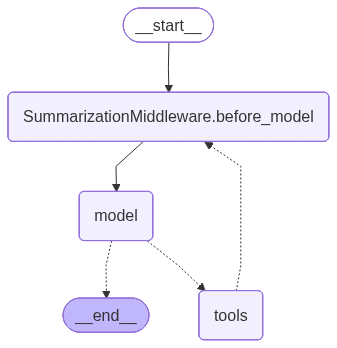

In [12]:
from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_community.retrievers import WikipediaRetriever
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from utils import format_messages


retriever = WikipediaRetriever(
    top_k_results=1,
    doc_content_chars_max=8_000,
)


@tool
def fetch_wikipedia_data(query: str) -> str:
    """Fetch content of the Wikipedia page from the top hit for a query."""
    results = retriever.invoke(query)
    if results:
        return results[0].page_content
    return "(No data found)"


summary_prompt = """
Summarize the main thrust of this conversation. What have the human and assistant
discussed so far? Focus on key facts and requests.
<messages>
Messages to summarize:
{messages}
</messages>
"""


research_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[fetch_wikipedia_data],
    system_prompt=(
        "You are a concise research assistant. "
        "Use Wikipedia to gather facts across the conversation. "
        "When asked for a final answer, combine the important facts into a short, clear summary."
    ),
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="openai:gpt-4o-mini",
            summary_prompt=summary_prompt,
            # Trigger summarization when 70% of context is used.
            trigger=("fraction", 0.7),
            # Keep the most recent 30% of messages in full.
            keep=("fraction", 0.3),
            # No additional trimming before summarization.
            trim_tokens_to_summarize=None,
        ),
    ],
)


config = {"configurable": {"thread_id": "ai-history-wikipedia-demo"}}

conversation_turns = [
    "Look up Ada Lovelace on Wikipedia.",
    "Now look up Alan Turing on Wikipedia.",
    "Now look up Andrej Karpathy on Wikipedia.",
    "Using everything so far, summarize the path from early computing to modern AI.",
]

for user_message in conversation_turns:
    result = research_agent.invoke(
        {"messages": [{"role": "user", "content": user_message}]},
        config=config,
    )


format_messages(result["messages"])

display(Image(research_agent.get_graph(xray=True).draw_mermaid_png()))

<img src="assets/ResearchAgent.svg" alt="Agent Summarization Middleware Overview" width="450"/>

### Research Agent With Summarization Middleware Retrospective

- The summarization middleware compressed older research context while keeping recent messages available.
- This helps the agent combine information from several Wikipedia lookups without carrying the full conversation forever.
- To view the summarized state and tool calls interactively, expose this research agent in `langgraph.json` and run `langgraph dev`. For hosted/persistent traces across runs, enable LangSmith tracing with `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`.


## LangSmith Studio

- Run the examples in `module-1/studio` with `langgraph dev` to inspect each agent in LangGraph Studio.
- Studio lets you view messages, tool calls, interrupts, state, and traces for each middleware example.
- These examples use LangChain middleware with `create_agent`, which is the simplest way to add behavior around an agent loop.